In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

C:\Users\Santosh Sreekar\AppData\Local\Temp\ipykernel_28240\3477529286.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv("clustering_data.csv")


<Axes: xlabel='Longitude', ylabel='Latitude'>

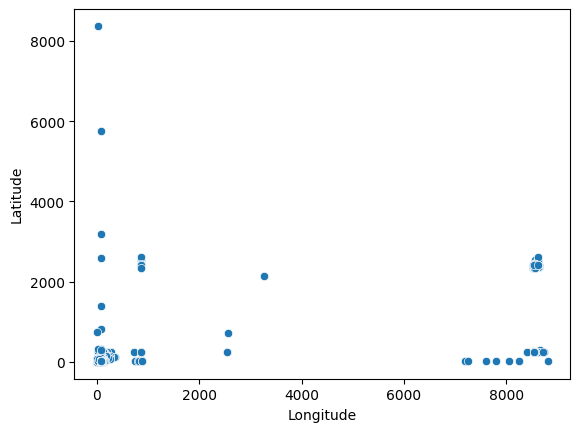

In [2]:
data=pd.read_csv("clustering_data.csv")
data.head()
data['Latitude'] = pd.to_numeric(data['Latitude'], errors='coerce')
data['Longitude'] = pd.to_numeric(data['Longitude'], errors='coerce')
import seaborn as sns
sns.scatterplot(x=data['Longitude'],y=data['Latitude'])



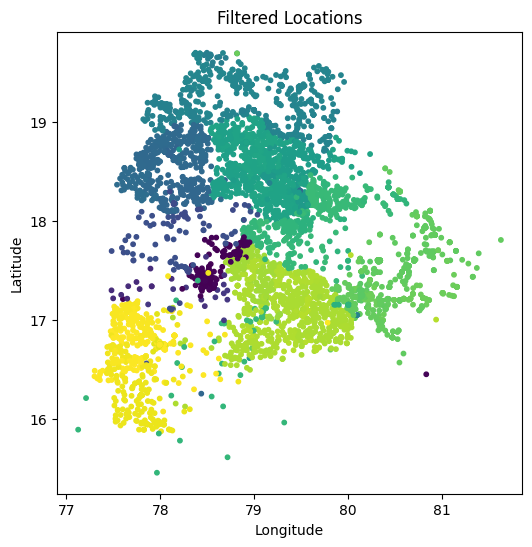

In [3]:
#Data Filtering:


# 1. CLEAN DATA

# Removing unwanted characters
data['Latitude'] = data['Latitude'].astype(str).str.replace('[^0-9.-]', '', regex=True)#replaces any character that is not a digit, a dot, or a minus sign with an empty string
data['Longitude'] = data['Longitude'].astype(str).str.replace('[^0-9.-]', '', regex=True)

# Fix trailing minus like "17.5-"
data['Latitude'] = data['Latitude'].str.replace(r'(\d+\.?\d*)-$', r'-\1', regex=True)
data['Longitude'] = data['Longitude'].str.replace(r'(\d+\.?\d*)-$', r'-\1', regex=True)

# Converting to numeric
data['Latitude'] = pd.to_numeric(data['Latitude'], errors='coerce')
data['Longitude'] = pd.to_numeric(data['Longitude'], errors='coerce')


# 2. FILTER DATA

data_filtered = data.loc[
    (data['StateName'] == 'TELANGANA') &
    (data['Latitude'].between(15.4, 19.7)) &
    (data['Longitude'].between(77, 82))
].dropna().reset_index(drop=True)

# 3. VISUALIZE DATA

plt.figure(figsize=(6,6))
plt.scatter(data_filtered['Longitude'], data_filtered['Latitude'],c=data_filtered['Pincode'],s=10)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Filtered Locations")
plt.show()





<Axes: xlabel='Longitude', ylabel='Latitude'>

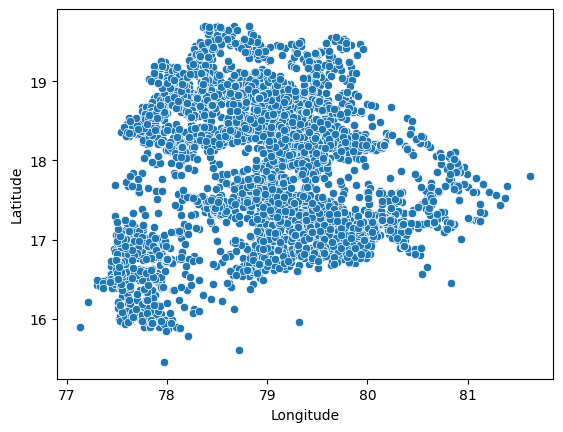

In [4]:
import seaborn as sns
data_filtered["Longitude"]=data_filtered["Longitude"].astype(float)
data_filtered["Latitude"]=data_filtered["Latitude"].astype(float)
sns.scatterplot(x=data_filtered["Longitude"],y=data_filtered["Latitude"])


In [7]:
#implementing K-Means from scratch:

#1. defining the distance function:
def dist(pt1,pt2):
    return np.linalg.norm(pt1-pt2)

#2. given centroids and data points, assign each data point to the nearest centroid:
def assign_clusters(data,centroids):
    clusters=[]
    for pt in data:
        distances=[]
        for centroid in centroids:
            distance=dist(pt,centroid)
            distances.append(distance)
        
        cluster=int(np.argmin(distances))
        clusters.append(cluster)
    return clusters

#3. given all the clusteres , we neede to update centroids to the mean of the data points in each cluster:
def update_centroids(data,clusters,k):
    new_centroids=[]
    for i in range(k):
        cluster_points=[]
        for j in range(len(data)):
            if(clusters[j]==i):
                cluster_points.append(data[j])
        if len(cluster_points) > 0:
            new_centroids.append(np.mean(cluster_points, axis=0))
        
        else:
            new_centroids.append(data[np.random.randint(len(data))])
        
    return np.array(new_centroids)

#4. main function

def k_means(data,k,max_iters=100):
    #Randomly initialize centroids
    indices=np.random.choice(len(data),size=k,replace=False)
    centroids=np.array(data[indices])
    
    
    for i in range(max_iters):
        clusters=assign_clusters(data,centroids)
        new_centroids=update_centroids(data,clusters,k)

        if np.allclose(new_centroids, centroids):
            
            break
        centroids = new_centroids
        
    return centroids,clusters
    




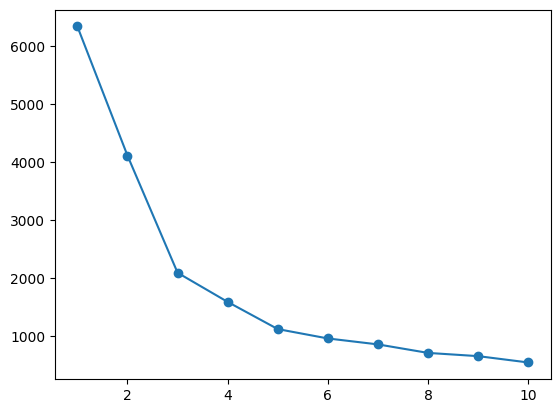

In [11]:
#executing on our data:
data_points=data_filtered[["Latitude","Longitude"]].values
#ELBOW METHOD:
k=[1,2,3,4,5,6,7,8,9,10]
variance=[]
for i in k:
    var=0
    centroids,clusters= k_means(data_points, i)
    clusters=np.array(clusters)
    for j in range(i):
        points= data_points[clusters==j]
        var+=np.sum(np.linalg.norm(points-centroids[j], axis=1)**2)
    variance.append(var)
plt.plot(k, variance, marker='o')    


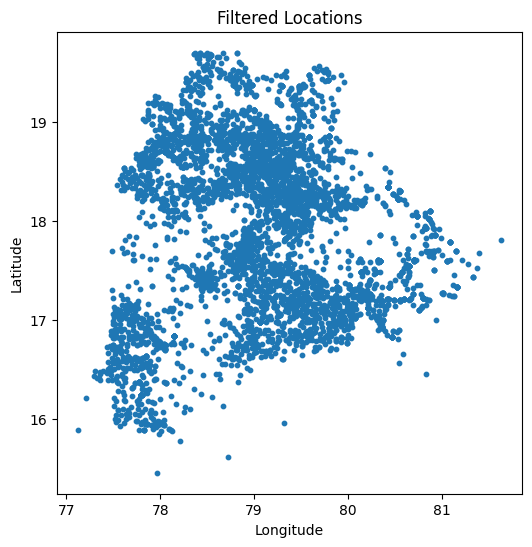

{0, 1, 2, 3, 4}


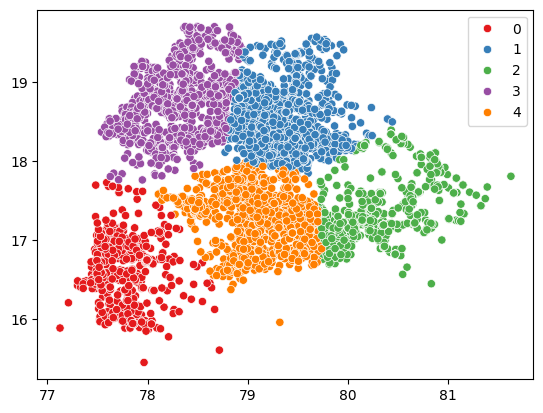

In [12]:
# By observing the plot we can say that elbow is at k=5.
k=5
centroids,clusters=k_means(data_points,k)

plt.figure(figsize=(6,6))
plt.scatter(data_points[:,1], data_points[:,0], s=10)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Filtered Locations")
plt.show()

sns.scatterplot(x=data_points[:,1],y=data_points[:,0],hue=clusters,palette="Set1")
print(set(clusters))

In [ ]:
##ANALYSIS:
#by taking k=5 we can see that almost it is matching with the original pincode clusters.
#we can also see that there are some outliers which are not matching with the original pincode clusters.
